### Метрики точности модели классификации

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

churn_df = pd.read_csv('telecom_churn_clean.csv')
X = churn_df[['total_day_charge','total_eve_charge']].values
y = churn_df['churn'].values
knn = KNeighborsClassifier(n_neighbors=7)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))


[[561  11]
 [ 63  32]]


In [2]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.98      0.94       572
           1       0.74      0.34      0.46        95

    accuracy                           0.89       667
   macro avg       0.82      0.66      0.70       667
weighted avg       0.88      0.89      0.87       667



### Логистическая регрессия

In [5]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[572   0]
 [ 94   1]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       572
           1       1.00      0.01      0.02        95

    accuracy                           0.86       667
   macro avg       0.93      0.51      0.47       667
weighted avg       0.88      0.86      0.80       667



In [ ]:
y_pred_probs = logreg.predict_proba(X_test)[:, 1]
print(y_pred_probs)

[0.12424795 0.12565853 0.20630404 0.25913054 0.08313444 0.08598255
 0.12877177 0.11885819 0.13251523 0.269296   0.13851785 0.05087126
 0.15029508 0.05730288 0.10584944 0.06327579 0.0804024  0.19278354
 0.19424319 0.12865731 0.04039683 0.14971316 0.03982896 0.11380576
 0.02799441 0.24144683 0.07631205 0.18634633 0.29002235 0.13601763
 0.17056538 0.32866513 0.09087711 0.17879885 0.14602913 0.04641269
 0.11264956 0.20898653 0.11507014 0.1108039  0.06987118 0.21755253
 0.2019114  0.20328156 0.1972818  0.07049685 0.13034735 0.21054693
 0.06698949 0.15770682 0.23990626 0.09342615 0.08016012 0.22343979
 0.21207456 0.0762697  0.03849594 0.11260835 0.12775327 0.08977548
 0.0508243  0.11761498 0.02172259 0.18905439 0.02554124 0.19383831
 0.04213139 0.09725156 0.10708464 0.20345335 0.08738319 0.26885299
 0.07053717 0.07071116 0.07294599 0.14919528 0.31287604 0.11895783
 0.14657729 0.21832464 0.07814358 0.22698397 0.12054072 0.16918866
 0.36105897 0.08097918 0.20637899 0.20614068 0.38075102 0.1656

### ROC-кривая

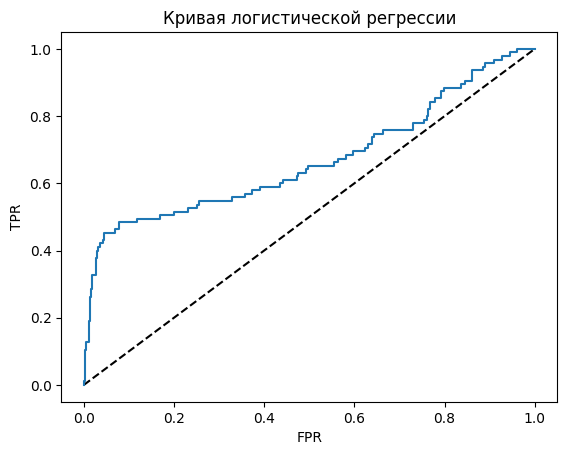

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, tresholds = roc_curve(y_test, y_pred_probs)
plt.plot([0, 1], [0,1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Кривая логистической регрессии')
plt.show()

In [9]:
print(roc_auc_score(y_test, y_pred_probs))

0.6682922340817078


### Поиск по сетки кроссвалидации

In [10]:
diabetes_df = pd.read_csv('diabetes_clean.csv')
diabetes_df = diabetes_df[diabetes_df['bmi'] > 0]
diabetes_df = diabetes_df[diabetes_df['glucose'] > 0]
diabetes_df = diabetes_df[diabetes_df['insulin'] > 0]
diabetes_df = diabetes_df[diabetes_df['diastolic'] > 0]
diabetes_df = diabetes_df[diabetes_df['triceps'] > 0]
diabetes_df = diabetes_df[diabetes_df['dpf'] > 0]
diabetes_df = diabetes_df[diabetes_df['age'] > 0]
X = diabetes_df.drop('glucose', axis=1).values
y = diabetes_df['glucose'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26)


In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import Ridge
kf = KFold(n_splits=10, shuffle=True, random_state=26)

param_grid = {'alpha': np.linspace(0.0001, 1, 10), 'solver': ['sag', 'lsqr']}
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv=kf)
ridge_cv.fit(X_train, y_train)
print(ridge_cv.best_params_, ridge_cv.best_score_)

{'alpha': np.float64(0.0001), 'solver': 'sag'} 0.03802511083862496


In [13]:
kf = KFold(n_splits=10, shuffle=True, random_state=26)

param_grid = {'alpha': np.linspace(0.0001, 1, 10), 'solver': ['sag', 'lsqr']}
ridge = Ridge()
ridge_cv = RandomizedSearchCV(ridge, param_grid, cv=kf, n_iter=5)
ridge_cv.fit(X_train, y_train)
print(ridge_cv.best_params_, ridge_cv.best_score_)

{'solver': 'sag', 'alpha': np.float64(1.0)} 0.03803085976120322
